Name: Se Rang Seo (Simon)

Professor: Dr. Romanowsky

Course: Phys255 Machine Learning

# About

The topic I am going to choose is going to be medical science. I’m going to use this article. This article is a statistical study done on German patients aged 65 and above with chronic diseases such as: hypertension, diabetes, cancer, heart failure, and so on. There are a total of around 840,000 patients: 42% male and 56% female. The reason for this study was to analyze the general public’s health in elderly patients in Germany while the conclusion they found was that chronic disease was high for German elders and that hypertension was the highest chronic disease for 25% of the patients.

https://datadryad.org/dataset/doi:10.5061/dryad.qh0h1#usage

https://journals.publisso.de/en/journals/gms/volume14/000230


### Chronic Diseases:

$\bf{Hypertension}$ or High Blood Pressure: a common condition where the force of blood against the artery walls is consistently too high. This can lead to serious health issues, including heart disease and stroke

$\bf{CHD}$ (Coronary Heart Disease) or Ischemic Heart Diease: a type of heart disease involving the reduction of blood flow to the cardiac muscle due to a build-up of atheromatous plaque in the arteries of the heart.

$\bf{Lipid}$ Disorder: the most common type of heart disease and the leading cause of death in the United States. It occurs when the coronary arteries become narrowed or blocked due to the buildup of atheromatous plaque, which reduces blood flow to the heart muscle

$\bf{Stroke}$: the blood supply to part of the brain is blocked or reduced

$\bf{Heart Failure}$ or Congestive Heart Failure: a chronic condition where the heart muscle is unable to pump enough blood to meet the body's needs for blood and oxygen. 

$\bf{Cancer}$: a disease in which some of the body’s cells grow uncontrollably and spread to other parts of the body

$\bf{Diabetes}$: a condition that happens when your blood sugar (glucose) is too high. It develops when your pancreas doesn’t make enough insulin or any at all, or when your body isn’t responding to the effects of insulin properly.

$\bf{COPD}$ (Chronic Obstructive Pulmonary Disease): a progressive lung disease that makes it difficult to breathe, primarily caused by long-term exposure to irritants like cigarette smoke and air pollution.

$\bf{Osteoporosis}$: a bone disease characterized by weak and fragile bones, increasing the risk of fractures

$\bf{Chronic Kidney Disease}$: your kidneys slowly get damaged and can't do important jobs like removing waste and keeping blood pressure normal

# Imports

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
#pip install pandas openpyxl
#pip install xlrd

# Dataset

In [61]:
dataset = pd.read_excel('CDset.xls')

In [62]:
dataset

,patient,male_gender,age,Hypertension,CHD,Lipid_disorder,Stroke,Heart_failure,Cancer,Diabetes,COPD,Osteoporosis,Chronic_kidney_disease
0,1,1,68,1,0,1,0,0,0,0,0,0,0
1,2,0,78,1,0,0,0,0,0,0,0,1,0
2,3,0,78,0,0,0,0,0,0,0,0,0,0
3,4,0,92,0,0,1,0,0,0,0,0,1,0
4,5,1,73,1,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,1,80,1,1,1,0,0,0,0,0,0,0
9996,9997,0,67,1,0,1,0,0,0,0,0,0,0
9997,9998,0,90,0,0,0,0,0,0,0,0,0,0
9998,9999,0,67,0,0,0,0,0,1,0,0,0,0


### Gender 
1 is male and 0 is female

1 is yes and 0 is no

In [63]:
dataset.head()

,patient,male_gender,age,Hypertension,CHD,Lipid_disorder,Stroke,Heart_failure,Cancer,Diabetes,COPD,Osteoporosis,Chronic_kidney_disease
0,1,1,68,1,0,1,0,0,0,0,0,0,0
1,2,0,78,1,0,0,0,0,0,0,0,1,0
2,3,0,78,0,0,0,0,0,0,0,0,0,0
3,4,0,92,0,0,1,0,0,0,0,0,1,0
4,5,1,73,1,0,1,0,0,0,0,0,0,0


I think I should drop the patient number and age. Age is not too important since we are, in general, studying elderly patients, so whether they are 70 or 95, they are elderly people.
I will also drop nulls, although I don't see any.

In [64]:
dropnaset = dataset.dropna()
dropnaset = dropnaset.drop(columns=['patient'], axis=1)
binaryset = dropnaset.drop(columns=['age'], axis=1)

binaryset

,male_gender,Hypertension,CHD,Lipid_disorder,Stroke,Heart_failure,Cancer,Diabetes,COPD,Osteoporosis,Chronic_kidney_disease
0,1,1,0,1,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,1,0
4,1,1,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,1,1,1,1,0,0,0,0,0,0,0
9996,0,1,0,1,0,0,0,0,0,0,0
9997,0,0,0,0,0,0,0,0,0,0,0
9998,0,0,0,0,0,0,1,0,0,0,0


In [65]:
setlist = [col for col in binaryset.columns]

for i in setlist:
    print(binaryset[i].value_counts())
    print(f"Ratio: {binaryset[i].value_counts()[1]/(binaryset[i].value_counts()[0]+binaryset[i].value_counts()[1])*100:.2f}%",'\n')

male_gender
0    5817
1    4183
Name: count, dtype: int64
Ratio: 41.83% 

Hypertension
1    6712
0    3288
Name: count, dtype: int64
Ratio: 67.12% 

CHD
0    7426
1    2574
Name: count, dtype: int64
Ratio: 25.74% 

Lipid_disorder
0    5880
1    4120
Name: count, dtype: int64
Ratio: 41.20% 

Stroke
0    9373
1     627
Name: count, dtype: int64
Ratio: 6.27% 

Heart_failure
0    8431
1    1569
Name: count, dtype: int64
Ratio: 15.69% 

Cancer
0    8287
1    1713
Name: count, dtype: int64
Ratio: 17.13% 

Diabetes
0    6856
1    3144
Name: count, dtype: int64
Ratio: 31.44% 

COPD
0    8711
1    1289
Name: count, dtype: int64
Ratio: 12.89% 

Osteoporosis
0    8707
1    1293
Name: count, dtype: int64
Ratio: 12.93% 

Chronic_kidney_disease
0    8699
1    1301
Name: count, dtype: int64
Ratio: 13.01% 



None of my data is balanced so I will not be using accuracy as a metric.

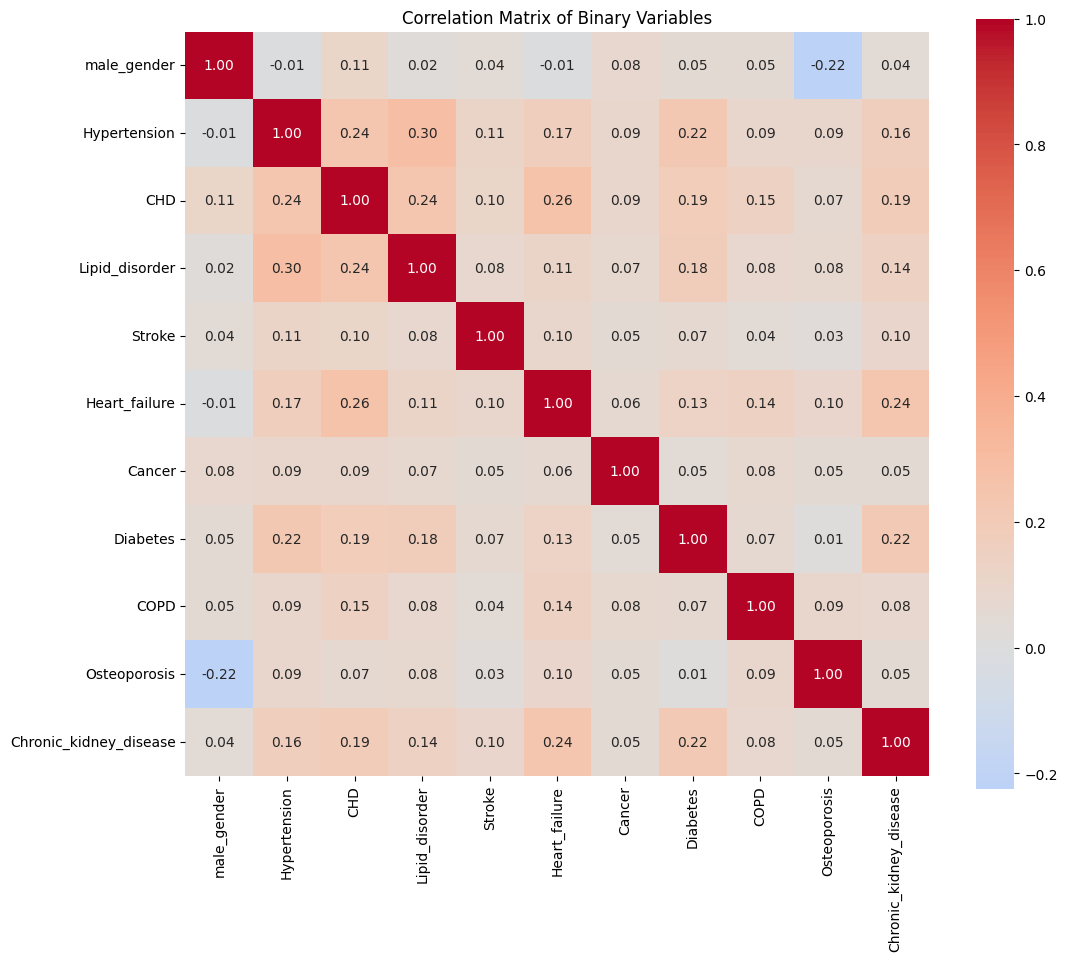

In [66]:
# Correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(binaryset.corr(), annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True)
plt.title('Correlation Matrix of Binary Variables')
plt.show()

Osteoporosis is less common for men.

Liquid disorder and hypertension are related.

In [67]:
# Calculate correlation matrix
corr_matrix = binaryset.corr()

# Get upper triangle of correlation matrix (excluding diagonal)
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Stack and sort correlations
corr_pairs = upper_triangle.stack().sort_values(ascending=False)

# Display highest correlations
print("Highest Correlations (Top 10):")
print(corr_pairs.head(10))
print("\nLowest Correlations (Bottom 10):")
print(corr_pairs.tail(10))

Highest Correlations (Top 10):
Hypertension    Lipid_disorder            0.296536
CHD             Heart_failure             0.259815
                Lipid_disorder            0.243281
Hypertension    CHD                       0.240682
Heart_failure   Chronic_kidney_disease    0.236093
Hypertension    Diabetes                  0.222711
Diabetes        Chronic_kidney_disease    0.218944
CHD             Chronic_kidney_disease    0.191135
                Diabetes                  0.186092
Lipid_disorder  Diabetes                  0.178401
dtype: float64

Lowest Correlations (Bottom 10):
Cancer       Diabetes                  0.045981
male_gender  Stroke                    0.042419
Stroke       COPD                      0.040845
male_gender  Chronic_kidney_disease    0.039044
Stroke       Osteoporosis              0.031877
male_gender  Lipid_disorder            0.018783
Diabetes     Osteoporosis              0.011222
male_gender  Hypertension             -0.010629
             Heart_failure

There's certain correlations where it's about .20, so they might be too strong and can mess with the training.
Like lipid disorder and hypertension are ~ .30 while the average is around .1

# Creating Pairplot

Create a pairplot to see if I can detect stroke or cancer.

In [68]:
stroke_list = [col for col in dropnaset.columns if (col != "Stroke")]

stroke_list

['male_gender',
 'age',
 'Hypertension',
 'CHD',
 'Lipid_disorder',
 'Heart_failure',
 'Cancer',
 'Diabetes',
 'COPD',
 'Osteoporosis',
 'Chronic_kidney_disease']

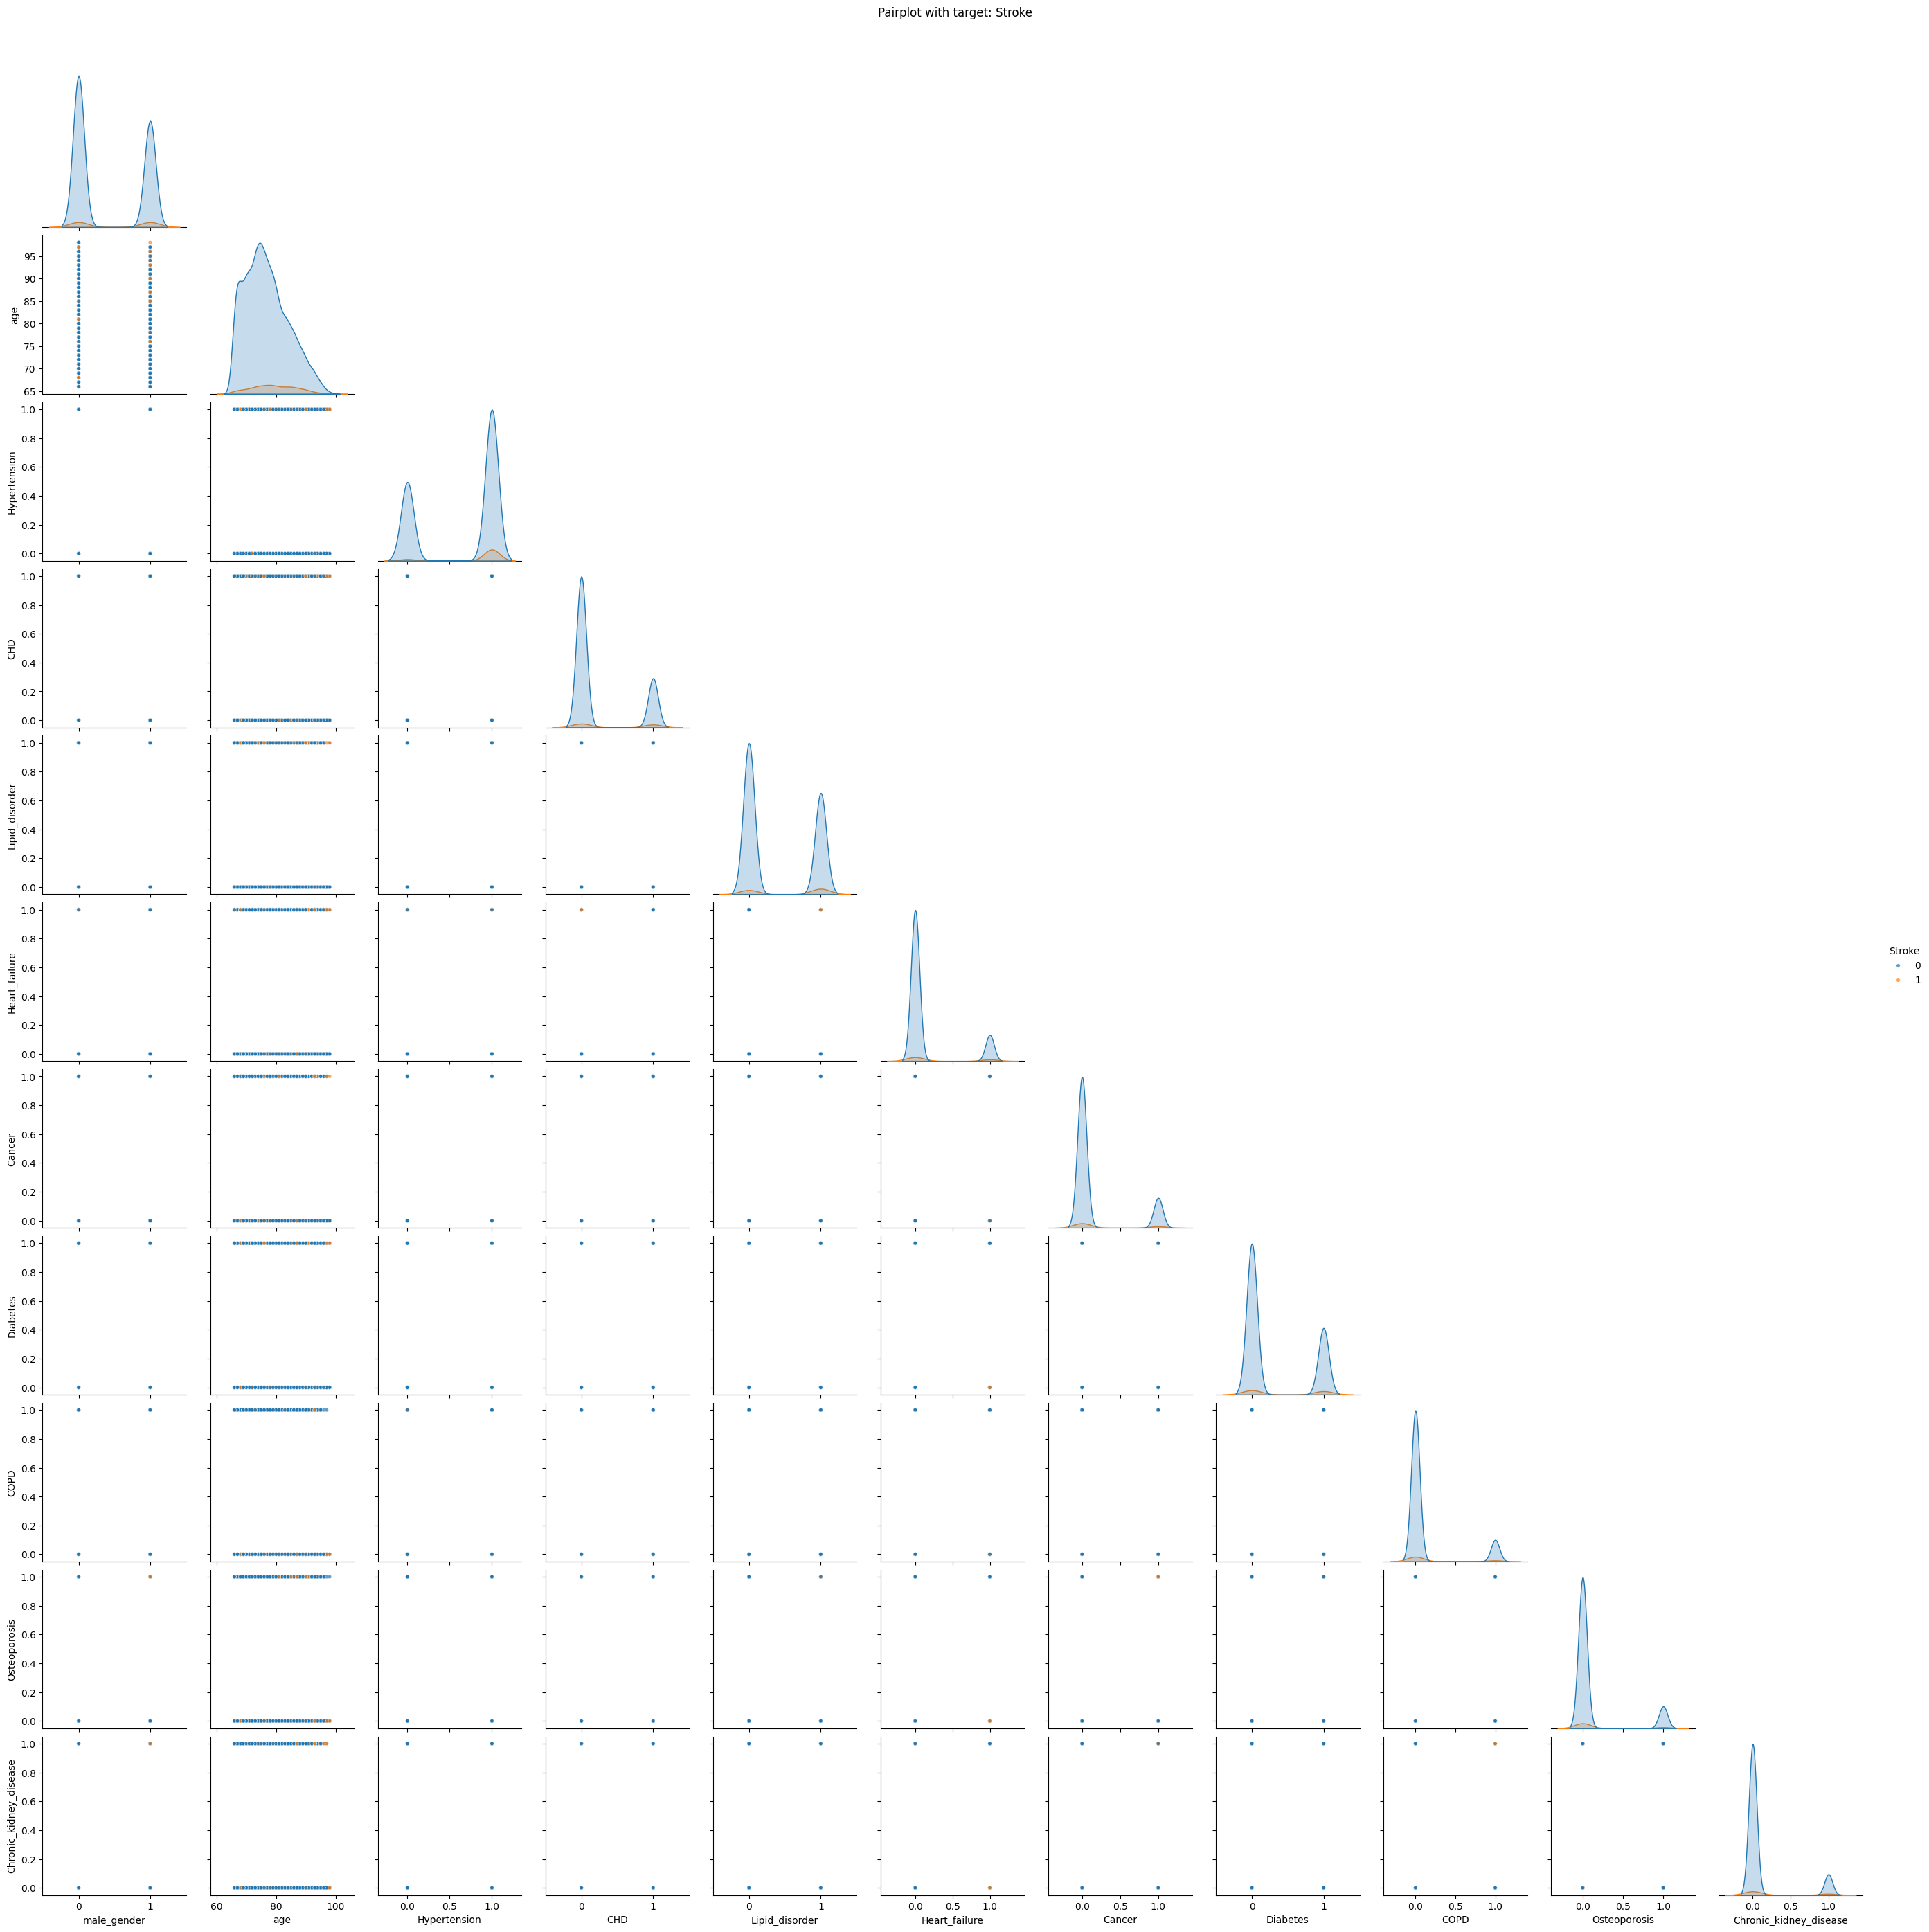

In [69]:
sns.pairplot(dropnaset, vars=stroke_list, hue="Stroke", plot_kws={"s":15,"alpha":0.7}, corner=True)
plt.suptitle("Pairplot with target: Stroke", y=1.02)
plt.show()

In [70]:
cancer_list = [col for col in dropnaset.columns if (col != "Cancer")]

cancer_list

['male_gender',
 'age',
 'Hypertension',
 'CHD',
 'Lipid_disorder',
 'Stroke',
 'Heart_failure',
 'Diabetes',
 'COPD',
 'Osteoporosis',
 'Chronic_kidney_disease']

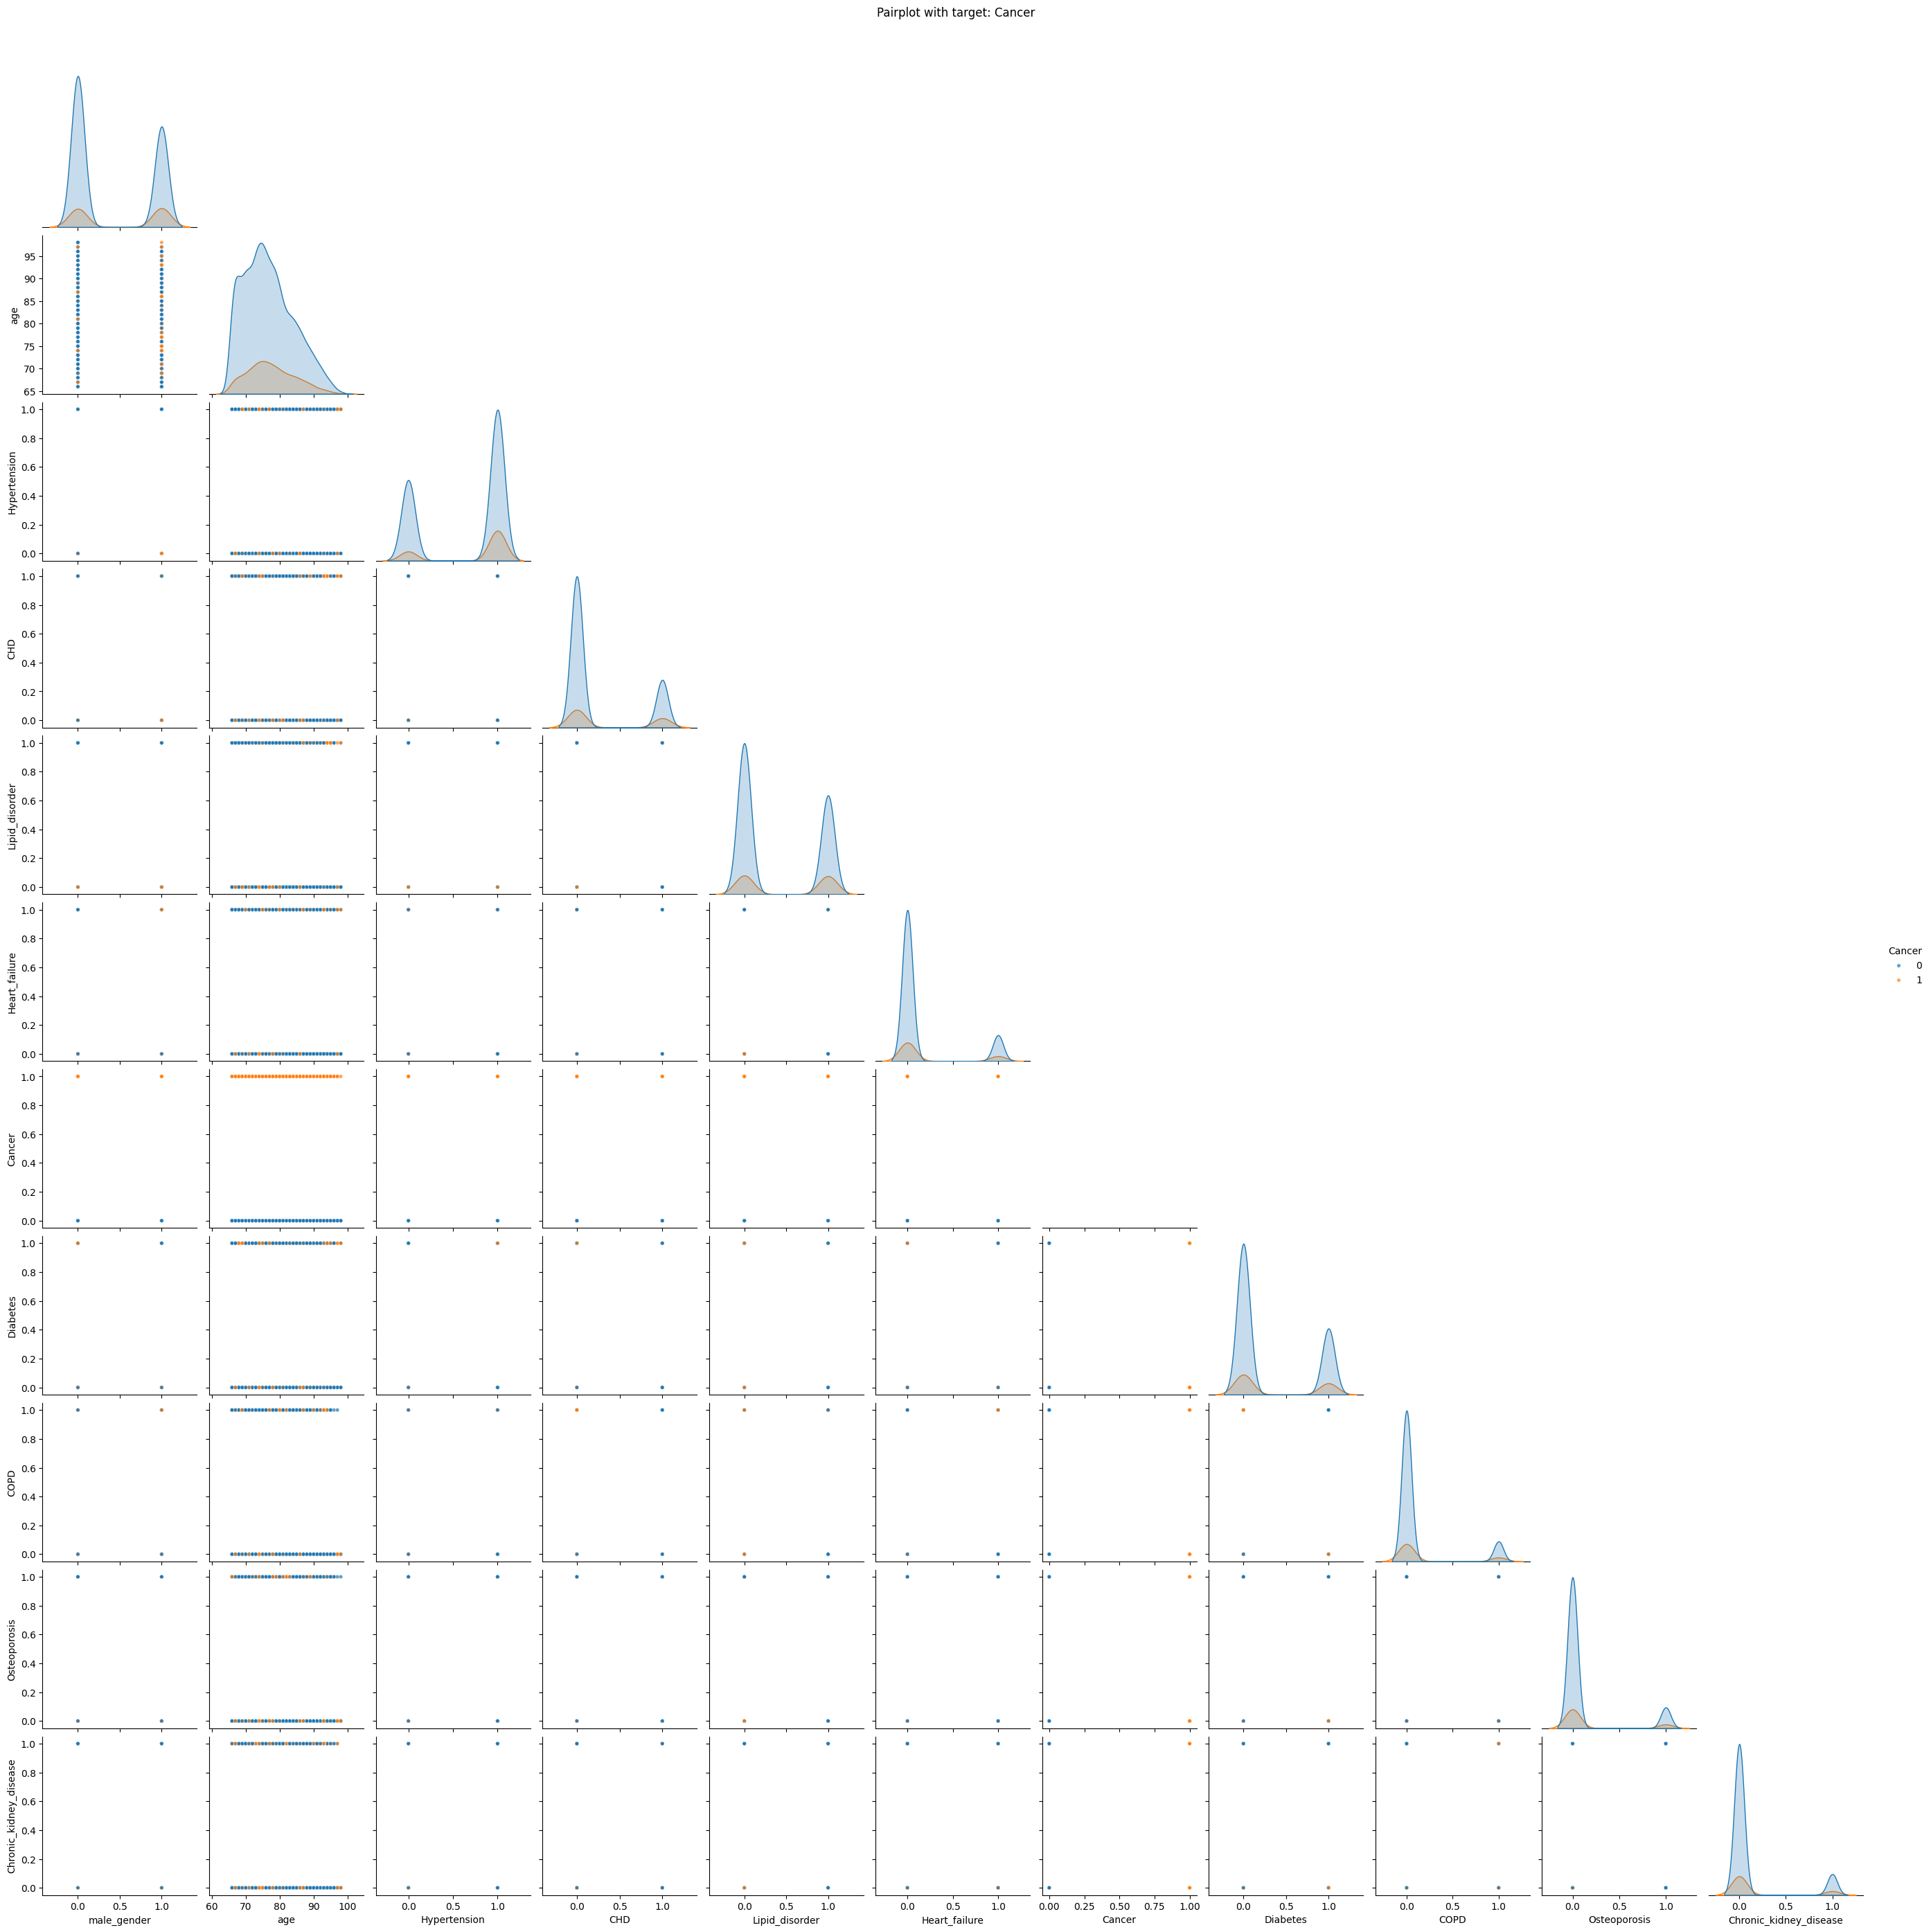

In [71]:
sns.pairplot(dropnaset, vars=stroke_list, hue="Cancer", plot_kws={"s":15,"alpha":0.7}, corner=True)
plt.suptitle("Pairplot with target: Cancer", y=1.02)
plt.show()

The dataset will not be balanced since I will be training 10 paramters to a single target. The metric I will be using is precision or recall. I won't be using accuracy since the dataset is not balanced

The method I would use is random forest classifier or a different classifier that's good for binary dataset.

In [77]:
hnp = pd.read_csv('HNP_StatsCSV.csv')
hnp = hnp.dropna()

hnp

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
7,Africa Eastern and Southern,AFE,Age dependency ratio (% of working-age populat...,SP.POP.DPND,8.896779e+01,8.932228e+01,8.968506e+01,9.012248e+01,9.055064e+01,9.101382e+01,...,8.537869e+01,8.465202e+01,8.388053e+01,8.303410e+01,8.223610e+01,8.143378e+01,8.063434e+01,7.987946e+01,7.914752e+01,7.843805e+01
8,Africa Eastern and Southern,AFE,"Age dependency ratio, old",SP.POP.DPND.OL,5.631545e+00,5.607333e+00,5.585546e+00,5.570575e+00,5.562311e+00,5.562341e+00,...,5.568049e+00,5.591522e+00,5.623820e+00,5.668747e+00,5.721924e+00,5.759325e+00,5.777143e+00,5.805446e+00,5.853275e+00,5.909405e+00
9,Africa Eastern and Southern,AFE,"Age dependency ratio, young",SP.POP.DPND.YG,8.297010e+01,8.331013e+01,8.365661e+01,8.407533e+01,8.450569e+01,8.498763e+01,...,7.874459e+01,7.803946e+01,7.727482e+01,7.637649e+01,7.551555e+01,7.466110e+01,7.382842e+01,7.303765e+01,7.225792e+01,7.149904e+01
189,Africa Eastern and Southern,AFE,Net migration,SM.POP.NETM,-1.027040e+05,-3.864600e+04,-5.641400e+04,-4.280900e+04,2.228000e+04,7.627000e+03,...,1.515280e+05,-7.998500e+05,3.409340e+05,3.270870e+05,1.007060e+05,3.401270e+05,1.875080e+05,-2.204280e+05,-9.899750e+05,-6.700140e+05
252,Africa Eastern and Southern,AFE,"Population ages 00-04, female",SP.POP.0004.FE,1.174069e+07,1.210613e+07,1.249128e+07,1.288571e+07,1.328634e+07,1.369776e+07,...,4.819452e+07,4.897825e+07,4.978173e+07,5.066366e+07,5.166971e+07,5.277677e+07,5.395244e+07,5.508517e+07,5.608680e+07,5.700915e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125953,Zimbabwe,ZWE,"Population, total",SP.POP.TOTL,3.809389e+06,3.930401e+06,4.055959e+06,4.185877e+06,4.320006e+06,4.458462e+06,...,1.439901e+07,1.460029e+07,1.481248e+07,1.503445e+07,1.527137e+07,1.552689e+07,1.579721e+07,1.606906e+07,1.634082e+07,1.663437e+07
126031,Zimbabwe,ZWE,Rural population,SP.RUR.TOTL,3.334472e+06,3.428659e+06,3.525543e+06,3.622149e+06,3.716752e+06,3.810562e+06,...,9.566522e+06,9.624522e+06,9.672329e+06,9.710970e+06,9.745612e+06,9.780423e+06,9.814932e+06,9.849444e+06,9.920197e+06,9.998361e+06
126032,Zimbabwe,ZWE,Rural population (% of total population),SP.RUR.TOTL.ZS,8.753299e+01,8.723433e+01,8.692255e+01,8.653262e+01,8.603581e+01,8.546808e+01,...,6.643874e+01,6.592005e+01,6.529850e+01,6.459145e+01,6.381624e+01,6.299023e+01,6.213079e+01,6.129448e+01,6.070806e+01,6.010663e+01
126073,Zimbabwe,ZWE,Urban population,SP.URB.TOTL,4.749170e+05,5.017420e+05,5.304160e+05,5.637280e+05,6.032540e+05,6.479000e+05,...,4.832491e+06,4.975772e+06,5.140153e+06,5.323482e+06,5.525756e+06,5.746465e+06,5.982278e+06,6.219612e+06,6.420625e+06,6.636012e+06
